# Prediction of Heavy Metal Concentrations (Pb, Cd)

### Overview

This notebook presents a machine learning experiment designed within a Data Stewardship framework, 
focusing on the prediction of missing environmental variables using existing observational data. 

The dataset consists of precipitation chemistry measurements collected across Austria.
It includes ion concentrations and selected heavy metals such as Lead (Pb) and Cadmium (Cd).

Due to incomplete spatial and temporal coverage, measurements of Pb and Cd are not available for all observations. 
This experiment addresses this limitation by training machine learning models 
to estimate these missing values based on other chemical and environmental variables.

**Source** 

*Concentrations of major ions in wet precipitation samples in Austria*

https://researchdata.tuwien.ac.at/records/b0g4h-rv840

### Authors and Contacts
- Federico Ambrogi, 01449911@student.tuwien.ac.at
- Amin Saad Rashidul 
- Farooq Mian Azan
- Vijayalakshmi Puthenpurayil Biju 

### Imports

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing import *
from src.models import *
from src.evaluation import *
from src.utils import *

from sklearn.model_selection import train_test_split
import pandas as pd

import pickle

### Load and Prepare Data

In [2]:
# Loading precipitation data into a pandas dataframe 
# Will try DBRepo
# Else from Local File 
# (Useful for comaprison and debugging) 

try:
    # Loading from DBRepo
    df: pd.DataFrame = load_data(path=False)
    print('Loaded DBRepo data')
    # Loading from local csv
except Exception as err:
    csv_path = "../data/precipitationdata.csv"
    print('Failed DBRepo, Loaded CSV data')
    df: pd.DataFrame = load_data(path=csv_path)
    
print(df.head(3))

# Forcing DBRepo loading
# df: pd.DataFrame = load_data(path=False)

Failed DBRepo, Loaded CSV data
        Datum Ort   NS  NS_flag     LF  LF_flag    pH  pH_flag    NH4  \
0  2014-10-01  SO  6.7      1.0   4.05      1.0  5.52      1.0  0.158   
1  2014-10-01  AF  1.4      1.0  16.95      1.0  5.72      1.0  1.187   
2  2014-10-01  LI  3.8      1.0    NaN      7.0   NaN      7.0    NaN   

   NH4_flag  ...     Cl  Cl_flag    NO3  NO3_flag    SO4  SO4_flag       Pb  \
0       1.0  ...  0.016      1.0  0.493       1.0  0.573       1.0  0.00017   
1       1.0  ...  0.105      1.0  4.417       1.0  1.424       1.0      NaN   
2       7.0  ...    NaN      7.0    NaN       7.0    NaN       7.0      NaN   

   Pb_flag        Cd  Cd_flag  
0      1.0  0.032874      1.0  
1      7.0       NaN      7.0  
2      7.0       NaN      7.0  

[3 rows x 28 columns]


In [3]:
# Data Cleaning and selecting features 
df = clean_dataframe(df)
df = feature_engineering(df)

features = prepare_features(df)

In [4]:
# Create output directories
out_fig_dir = '../outputs/figures/'
if not os.path.isdir(out_fig_dir):
    os.makedirs(out_fig_dir)  
    print(" *** Created folder : ", out_fig_dir)

out_mod_dir = '../outputs/models/'
if not os.path.isdir(out_mod_dir):
    os.makedirs(out_mod_dir)
    print(" *** Created folder : ", out_mod_dir)

### Data Exploration

In [12]:
df.head()

,NS,LF,pH,NH4,Na,K,Ca,Mg,Cl,NO3,...,Ort_IV,Ort_LI,Ort_LU,Ort_MB,Ort_NB,Ort_NH,Ort_OS,Ort_SO,Ort_WW,date_ordinal
0,6.700000,4.05,5.52,0.158,0.030,0.0100,0.301,0.032,0.016,0.493,...,False,False,False,False,False,False,False,True,False,735507
1,1.400000,16.95,5.72,1.187,0.308,0.4690,0.398,0.066,0.105,4.417,...,False,False,False,False,False,False,False,False,False,735507
2,3.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,True,False,False,False,False,False,False,False,735507
3,11.500000,13.47,6.34,0.381,0.041,0.0100,0.081,0.010,0.038,1.788,...,False,False,True,False,False,False,False,False,False,735507
4,2.599653,4.40,5.77,0.376,0.025,0.0611,0.079,0.019,0.050,0.780,...,True,False,False,False,False,False,False,False,False,735507


In [14]:
df.columns

Index(['NS', 'LF', 'pH', 'NH4', 'Na', 'K', 'Ca', 'Mg', 'Cl', 'NO3', 'SO4',
       'Pb', 'Cd', 'Ort_DR', 'Ort_GS', 'Ort_HF', 'Ort_HG', 'Ort_IV', 'Ort_LI',
       'Ort_LU', 'Ort_MB', 'Ort_NB', 'Ort_NH', 'Ort_OS', 'Ort_SO', 'Ort_WW',
       'date_ordinal'],
      dtype='str')

In [18]:
import matplotlib.pyplot as plt

df_SO = df.loc[df['Ort_SO']==True ]

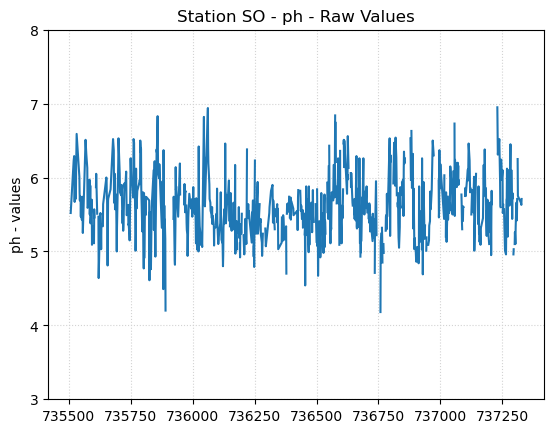

In [22]:
plt.plot(df_SO.date_ordinal, df_SO.pH)
plt.ylabel('ph - values')
ax = plt.gca()
ax.set_ylim([3, 8])
plt.grid(ls= ':', color = 'lightgray')
plt.title('Station SO - ph - Raw Values')
plt.show()


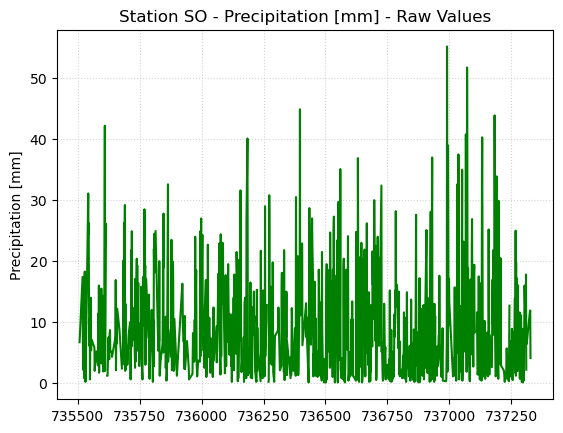

In [25]:
plt.plot(df_SO.date_ordinal, df_SO.NS, color='green')
plt.ylabel('Precipitation [mm]')
ax = plt.gca()
plt.grid(ls= ':', color = 'lightgray')
plt.title('Station SO - Precipitation [mm] - Raw Values')
plt.show()

### Pb from Sequential Approach

The value of the Pb concentration is first predcted, and then used to predict the Cd concentration

Metric:  ('rmse', 0.7426849303519103)
Metric:  ('mae', 0.12608539879114203)


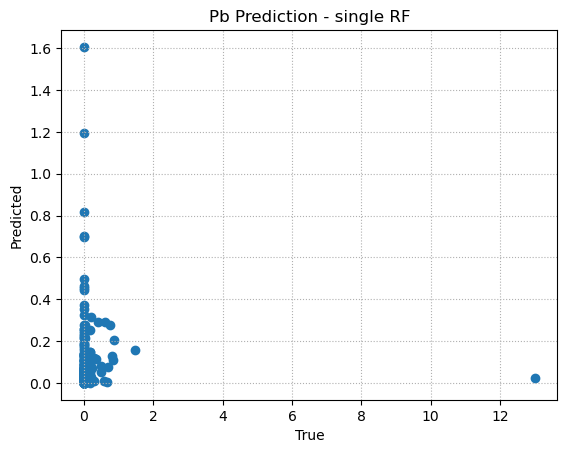

In [10]:
# ---- Pb ----
df_pb = df.dropna(subset=["Pb"])

X_pb = df_pb[features]
y_pb = df_pb["Pb"]

# Preparing train-test-split dataset 
X_train_pb, X_test_pb, y_train_pb, y_test_pb = train_test_split(
    X_pb, y_pb, test_size=0.2, random_state=42 )

#model_pb = train_pb_model(X_train_pb, y_train_pb)
model_pb = train_model(X_train_pb, y_train_pb)

# predictions
y_pred_pb = model_pb.predict(X_test_pb)

# metrics
metrics_pb = compute_metrics(y_test_pb, y_pred_pb)

# Metric Values
for metric in metrics_pb.items():
    print('Metric: ' , metric)

plot_prediction(y_test_pb, y_pred_pb,"Pb Prediction - single RF","../outputs/figures/fig_pb_prediction.png" )

### Cd from Sequential Model 
 

Metric:  ('rmse', 0.3170264664347827)
Metric:  ('mae', 0.07425637875107528)


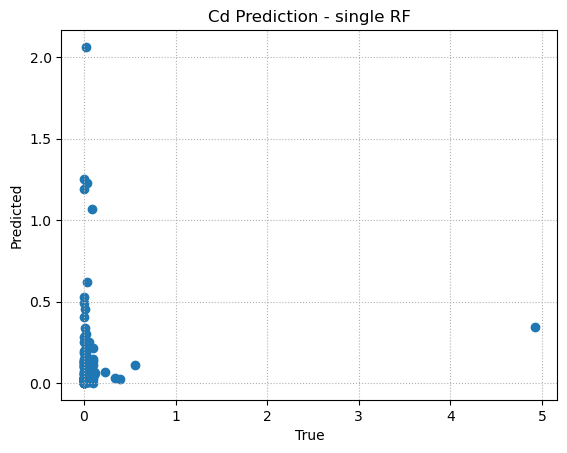

In [9]:
df_cd = df.dropna(subset=["Cd"])

X_cd_base = df_cd[features]
predicted_pb = model_pb.predict(X_cd_base)

X_cd = X_cd_base.copy()
X_cd["Pb_predicted"] = predicted_pb

y_cd = df_cd["Cd"]


# Preparing train-test-split dataset 
X_train_cd, X_test_cd, y_train_cd, y_test_cd = train_test_split(
    X_cd, y_cd, test_size=0.2, random_state=42
)


model_cd = train_model(X_train_cd, y_train_cd)

# saving model
save_model(model_cd, "../outputs/models/model_cd_randomforest.pkl")


import pickle
# save
with open('../outputs/models/model_cd_randomforest.pkl','wb') as f:
    pickle.dump(model_pb,f)

# for LOADING
#with open('TRY_DUMP.pkl', 'rb') as f:
#   clf2 = pickle.load(f)

# prediction
y_pred_cd = model_cd.predict(X_test_cd)

metrics_multi = compute_metrics(y_test_cd, y_pred_cd)

# Metric Values
for metric in metrics_multi.items():
    print('Metric: ' , metric)

# Plotting predictions
plot_prediction( y_test_cd, y_pred_cd, "Cd Prediction - single RF", "../outputs/figures/fig_cd_prediction.png" )


### Multi-output

In [ ]:
df_multi = df.dropna(subset=["Pb", "Cd"])

X_multi = df_multi[features]
Y_multi = df_multi[["Pb", "Cd"]]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, Y_multi, test_size=0.2, random_state=42
)


model_multi = train_model(X_train_m, y_train_m)

# saving model 
with open('../outputs/models/model_multi_randomforest.pkl','wb') as f:
    pickle.dump(model_pb,f)

# calculating predictions
y_pred_m = model_multi.predict(X_test_m)
y_pred_cd_m = y_pred_m[:, 1]

# calculating metrics
metrics_multi = compute_metrics(y_test_m["Cd"], y_pred_cd_m)


In [8]:
# Metric Values
for metric in metrics_multi.items():
    print('Metric: ' , metric)

Metric:  ('rmse', 0.28314260359442844)
Metric:  ('mae', 0.05817163297760345)


### Feature Importance

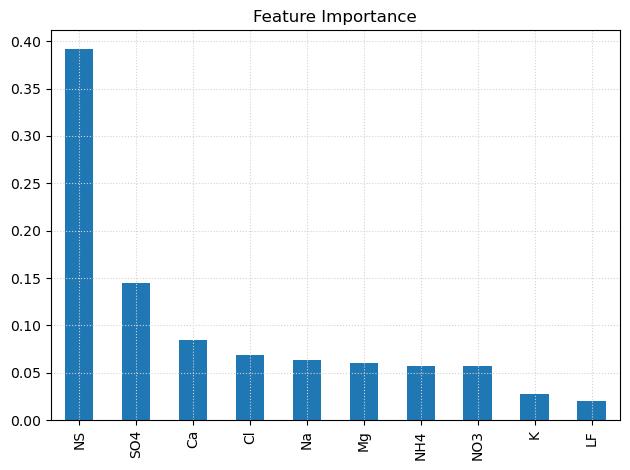

In [8]:
plot_feature_importance( model_pb, X_pb.columns, "../outputs/figures/fig_feature_importance_pb.png" )